# DeepLabV3+ Inference on test_data (10-Band + Indices Contract)

Loads `best_deeplabv3plus_10b.pth` and runs pixel-wise inference on `test_data` with the same metric outputs as the U-Net/RF inference flow.

Input feature contract: `B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,NDVI,NDBI,MNDWI,BSI,DBI,NSI`.

Class `0` is never emitted at inference; argmax is forced over classes 1..4.

In [19]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

PROJECT_DIR = Path(r'c:/satellite/project')
TEST_DATA_DIR = PROJECT_DIR / 'data/test_data'
MODEL_PATH = PROJECT_DIR / 'best_deeplabv3plus_1.pth'
METRICS_CSV = PROJECT_DIR / 'test_data_inference_metrics_deeplabv3plus_10b.csv'

DEFAULT_CLASS_NAMES = {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}
CLASS_COLORS = {1: 'darkgreen', 2: 'gold', 3: 'navy', 4: 'gray'}
CLASS_NAMES = DEFAULT_CLASS_NAMES
CLASS_IDS = sorted(CLASS_NAMES.keys())
ACTIVE_CLASSES = CLASS_IDS
EPS = 1e-6

POSTPROCESS_ENABLE = False
POSTPROCESS_WINDOW = 3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print(f'Postprocessing enabled: {POSTPROCESS_ENABLE} | window={POSTPROCESS_WINDOW}')

Device: cuda
Postprocessing enabled: False | window=3


In [20]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1, d=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, stride=s, padding=p, dilation=d, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class ASPP(nn.Module):
    def __init__(self, in_ch, out_ch=256, rates=(1, 6, 12, 18)):
        super().__init__()
        self.b0 = ConvBNReLU(in_ch, out_ch, k=1, p=0)
        self.b1 = ConvBNReLU(in_ch, out_ch, k=3, p=rates[1], d=rates[1])
        self.b2 = ConvBNReLU(in_ch, out_ch, k=3, p=rates[2], d=rates[2])
        self.b3 = ConvBNReLU(in_ch, out_ch, k=3, p=rates[3], d=rates[3])
        self.pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            ConvBNReLU(in_ch, out_ch, k=1, p=0),
        )
        self.proj = ConvBNReLU(out_ch * 5, out_ch, k=1, p=0)

    def forward(self, x):
        size = x.shape[-2:]
        p = self.pool(x)
        p = F.interpolate(p, size=size, mode='bilinear', align_corners=False)
        x = torch.cat([self.b0(x), self.b1(x), self.b2(x), self.b3(x), p], dim=1)
        return self.proj(x)

class DeepLabV3PlusSmall(nn.Module):
    def __init__(self, in_ch=16, n_classes=5, base=64):
        super().__init__()
        self.stem = nn.Sequential(
            ConvBNReLU(in_ch, base, k=3, s=2, p=1),
            ConvBNReLU(base, base, k=3, s=1, p=1),
        )
        self.low = nn.Sequential(
            ConvBNReLU(base, base * 2, k=3, s=2, p=1),
            ConvBNReLU(base * 2, base * 2, k=3, s=1, p=1),
        )
        self.high = nn.Sequential(
            ConvBNReLU(base * 2, base * 4, k=3, s=2, p=1),
            ConvBNReLU(base * 4, base * 4, k=3, s=1, p=1),
            ConvBNReLU(base * 4, base * 4, k=3, s=1, p=1),
        )

        self.aspp = ASPP(base * 4, out_ch=256)
        self.low_proj = ConvBNReLU(base * 2, 48, k=1, p=0)
        self.decoder = nn.Sequential(
            ConvBNReLU(256 + 48, 256, k=3, p=1),
            ConvBNReLU(256, 256, k=3, p=1),
            nn.Conv2d(256, n_classes, kernel_size=1),
        )

    def forward(self, x):
        input_hw = x.shape[-2:]
        x = self.stem(x)
        low = self.low(x)
        high = self.high(low)

        y = self.aspp(high)
        y = F.interpolate(y, size=low.shape[-2:], mode='bilinear', align_corners=False)
        low_feat = self.low_proj(low)
        y = torch.cat([y, low_feat], dim=1)
        y = self.decoder(y)
        y = F.interpolate(y, size=input_hw, mode='bilinear', align_corners=False)
        return y

In [21]:
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
model = DeepLabV3PlusSmall(
    in_ch=int(ckpt.get('in_channels', 16)),
    n_classes=int(ckpt.get('num_classes', 5)),
    base=64
).to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

CLASS_NAMES = ckpt.get('class_names', CLASS_NAMES)
CLASS_IDS = sorted(CLASS_NAMES.keys())
ACTIVE_CLASSES = CLASS_IDS

print('Loaded model:', ckpt.get('model_type', 'deeplabv3plus_small'))
print('Feature names:', ckpt.get('feature_names', []))
print('Classes:', CLASS_NAMES)

Loaded model: deeplabv3plus_small
Feature names: ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'NDBI', 'MNDWI', 'BSI', 'DBI', 'NSI']
Classes: {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}


In [22]:
spectral_files = sorted(TEST_DATA_DIR.glob('*_Spectral*.tif'))
mask_files = sorted(TEST_DATA_DIR.glob('*_Mask*.tif'))

def pair_id(path: Path) -> str:
    name = path.name
    name = name.replace('_Spectral_12B.tif', '')
    name = name.replace('_Spectral.tif', '')
    name = name.replace('_Mask_Class.tif', '')
    name = name.replace('_Mask.tif', '')
    return name

spectral_lookup = {pair_id(path): path for path in spectral_files}
mask_lookup = {pair_id(path): path for path in mask_files}
common_ids = sorted(set(spectral_lookup) & set(mask_lookup))
sample_pairs = [
    {'name': site_id, 'spectral_path': spectral_lookup[site_id], 'mask_path': mask_lookup[site_id]}
    for site_id in common_ids
]

print('Paired test samples:', [x['name'] for x in sample_pairs])
print('Unmatched spectral files:', len(set(spectral_lookup)-set(mask_lookup)))
print('Unmatched mask files:', len(set(mask_lookup)-set(spectral_lookup)))

Paired test samples: ['CairoUniv', 'HawaraFayoum', 'IconicTower', 'KarnakLuxor', 'PhilaeAswan', 'SiwaOasis']
Unmatched spectral files: 0
Unmatched mask files: 0


In [23]:
IDX_B2, IDX_B3, IDX_B4 = 1, 2, 3
IDX_B5, IDX_B6, IDX_B7 = 4, 5, 6
IDX_B8, IDX_B8A, IDX_B11, IDX_B12 = 7, 8, 10, 11

def normalize_spectral_10_from_test(cube12: np.ndarray) -> np.ndarray:
    x = np.stack([
        cube12[IDX_B2], cube12[IDX_B3], cube12[IDX_B4], cube12[IDX_B5], cube12[IDX_B6],
        cube12[IDX_B7], cube12[IDX_B8], cube12[IDX_B8A], cube12[IDX_B11], cube12[IDX_B12]
    ], axis=0).astype(np.float32)
    probe = np.nanpercentile(x, 99)
    if probe > 2.0:
        x = np.clip(x / 10000.0, 0.0, 1.0)
    else:
        x = np.clip(x, 0.0, 1.0)
    return x

def compute_spectral_indices(spectral_norm: np.ndarray) -> np.ndarray:
    b2 = spectral_norm[0]
    b3 = spectral_norm[1]
    b4 = spectral_norm[2]
    b8 = spectral_norm[6]
    b8a = spectral_norm[7]
    b11 = spectral_norm[8]

    ndvi = (b8 - b4) / (b8 + b4 + EPS)
    ndbi = (b11 - b8) / (b11 + b8 + EPS)
    mndwi = (b3 - b11) / (b3 + b11 + EPS)
    bsi = ((b11 + b4) - (b8 + b2)) / ((b11 + b4) + (b8 + b2) + EPS)
    dbi = ndbi - ndvi
    nsi = (b11 - b8a) / (b11 + b8a + EPS)

    return np.stack([ndvi, ndbi, mndwi, bsi, dbi, nsi], axis=0).astype(np.float32)

def build_deeplab_features_from_test(cube12: np.ndarray) -> np.ndarray:
    spectral_norm = normalize_spectral_10_from_test(cube12)
    indices = compute_spectral_indices(spectral_norm)
    return np.concatenate([spectral_norm, indices], axis=0).astype(np.float32)

def compute_per_class_iou(y_true: np.ndarray, y_pred: np.ndarray, class_ids):
    ious = {}
    for class_id in class_ids:
        inter = np.sum((y_true == class_id) & (y_pred == class_id))
        union = np.sum((y_true == class_id) | (y_pred == class_id))
        ious[class_id] = inter / union if union > 0 else np.nan
    return ious

def majority_vote_smoothing(label_map: np.ndarray, class_ids, window: int = 3) -> np.ndarray:
    if window <= 1:
        return label_map
    if window % 2 == 0:
        raise ValueError('POSTPROCESS_WINDOW must be odd for centered voting.')

    pad = window // 2
    padded = np.pad(label_map, ((pad, pad), (pad, pad)), mode='reflect')
    patches = np.lib.stride_tricks.sliding_window_view(padded, (window, window))

    class_ids = np.array(class_ids, dtype=np.int32)
    vote_counts = np.stack([
        np.sum(patches == class_id, axis=(-1, -2))
        for class_id in class_ids
    ], axis=-1)

    winners = np.argmax(vote_counts, axis=-1)
    return class_ids[winners].astype(label_map.dtype)

def make_rgb(spectral_cube: np.ndarray) -> np.ndarray:
    red = spectral_cube[IDX_B4].astype(np.float32)
    green = spectral_cube[IDX_B3].astype(np.float32)
    blue = spectral_cube[IDX_B2].astype(np.float32)
    rgb = np.stack([red, green, blue], axis=-1)
    p2, p98 = np.percentile(rgb, [2, 98])
    return np.clip((rgb - p2) / (p98 - p2 + EPS), 0, 1)

cmap_cls = ListedColormap([CLASS_COLORS[c] for c in CLASS_IDS])
bounds = np.arange(min(CLASS_IDS)-0.5, max(CLASS_IDS)+1.5, 1)
norm_cls = BoundaryNorm(bounds, ncolors=len(CLASS_IDS))
legend_patches = [mpatches.Patch(color=CLASS_COLORS[c], label=f'{c}: {CLASS_NAMES[c]}') for c in CLASS_IDS]

In [24]:
records = []
predictions_by_site = {}

expected_in_channels = int(ckpt.get('in_channels', 16))

with torch.no_grad():
    for sample_item in sample_pairs:
        sample_name = sample_item['name']

        with rasterio.open(sample_item['spectral_path']) as src:
            spectral_cube = src.read().astype(np.float32)

        with rasterio.open(sample_item['mask_path']) as src:
            y_true = src.read(1).astype(np.int32)

        x = build_deeplab_features_from_test(spectral_cube)
        if x.shape[0] != expected_in_channels:
            raise ValueError(
                f"Feature-channel mismatch for {sample_name}: built {x.shape[0]} but model expects {expected_in_channels}. "
                "Retrain model or align feature contract."
            )

        xb = torch.from_numpy(x).unsqueeze(0).to(DEVICE)
        logits = model(xb).squeeze(0)
        logits[0, :, :] = -torch.inf
        y_pred_raw = torch.argmax(logits, dim=0).cpu().numpy().astype(np.int32)

        if POSTPROCESS_ENABLE:
            y_pred = majority_vote_smoothing(y_pred_raw, CLASS_IDS, window=POSTPROCESS_WINDOW)
        else:
            y_pred = y_pred_raw

        valid_mask = y_true != 0
        y_true_valid = y_true[valid_mask]
        y_pred_valid = y_pred[valid_mask]

        ious = compute_per_class_iou(y_true_valid, y_pred_valid, ACTIVE_CLASSES)
        miou = float(np.nanmean([ious[c] for c in ACTIVE_CLASSES]))
        accuracy = float(np.mean(y_true_valid == y_pred_valid))

        row = {'sample': sample_name, 'accuracy': accuracy, 'mIoU_active': miou}
        for class_id in ACTIVE_CLASSES:
            row[f'IoU_{CLASS_NAMES[class_id]}'] = ious[class_id]
        records.append(row)

        predictions_by_site[sample_name] = {
            'spectral_cube': spectral_cube,
            'y_true': y_true,
            'y_true_valid': y_true_valid,
            'y_pred_raw': y_pred_raw,
            'y_pred': y_pred,
            'y_pred_valid': y_pred_valid
        }

metrics_df = pd.DataFrame(records).sort_values('mIoU_active', ascending=False).reset_index(drop=True)
metrics_df

,sample,accuracy,mIoU_active,IoU_Greenery,IoU_Sand,IoU_Water,IoU_Cement
0,SiwaOasis,0.908630,0.549524,0.785128,0.863444,NaN,0.000000
1,HawaraFayoum,0.906706,0.528278,0.894431,0.844310,0.000000,0.374370
2,CairoUniv,0.883698,0.428936,0.000000,0.000000,0.840079,0.875665
3,PhilaeAswan,0.910507,0.417694,0.000000,0.786645,0.884132,0.000000
4,KarnakLuxor,0.311661,0.355062,0.408278,0.130604,0.881366,0.000000
5,IconicTower,0.656555,0.322784,0.294191,0.651492,NaN,0.022667


Mean active-class mIoU: 0.4337
Mean accuracy: 0.763
Postprocessing enabled: False | window=3

Per-sample metrics:
SiwaOasis       mIoU=0.5495  acc=0.9086
HawaraFayoum    mIoU=0.5283  acc=0.9067
CairoUniv       mIoU=0.4289  acc=0.8837
PhilaeAswan     mIoU=0.4177  acc=0.9105
KarnakLuxor     mIoU=0.3551  acc=0.3117
IconicTower     mIoU=0.3228  acc=0.6566
              precision    recall  f1-score   support

    Greenery       0.90      0.85      0.87    107022
        Sand       0.84      0.71      0.77    186720
       Water       0.90      0.98      0.93     54477
      Cement       0.52      0.70      0.60     82955

    accuracy                           0.78    431174
   macro avg       0.79      0.81      0.79    431174
weighted avg       0.80      0.78      0.78    431174



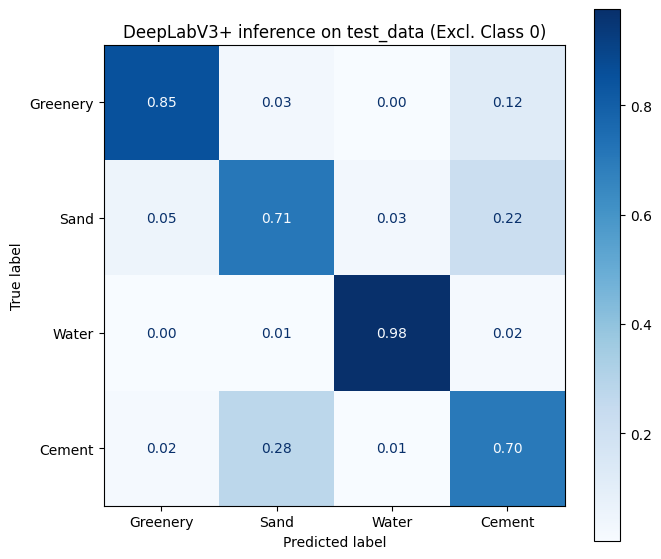

Predictions: (array([1, 2, 3, 4], dtype=int32), array([101789, 157962,  59326, 112097]))
Truth: (array([1, 2, 3, 4], dtype=int32), array([107022, 186720,  54477,  82955]))


In [25]:
print('Mean active-class mIoU:', round(metrics_df['mIoU_active'].mean(), 4))
print('Mean accuracy:', round(metrics_df['accuracy'].mean(), 4))
print(f'Postprocessing enabled: {POSTPROCESS_ENABLE} | window={POSTPROCESS_WINDOW}')
print('\nPer-sample metrics:')
for _, row in metrics_df.iterrows():
    print(f"{row['sample']:<15} mIoU={row['mIoU_active']:.4f}  acc={row['accuracy']:.4f}")

all_true = np.concatenate([predictions_by_site[k]['y_true_valid'] for k in predictions_by_site])
all_pred = np.concatenate([predictions_by_site[k]['y_pred_valid'] for k in predictions_by_site])

print(classification_report(
    all_true,
    all_pred,
    labels=CLASS_IDS,
    target_names=[CLASS_NAMES[c] for c in CLASS_IDS],
    zero_division=0
))

cm = confusion_matrix(all_true, all_pred, labels=CLASS_IDS, normalize='true')
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[CLASS_NAMES[c] for c in CLASS_IDS]).plot(
    ax=ax, cmap='Blues', values_format='.2f', colorbar=True
)
ax.set_title('DeepLabV3+ inference on test_data (Excl. Class 0)')
plt.tight_layout()
plt.show()

print('Predictions:', np.unique(all_pred, return_counts=True))
print('Truth:', np.unique(all_true, return_counts=True))

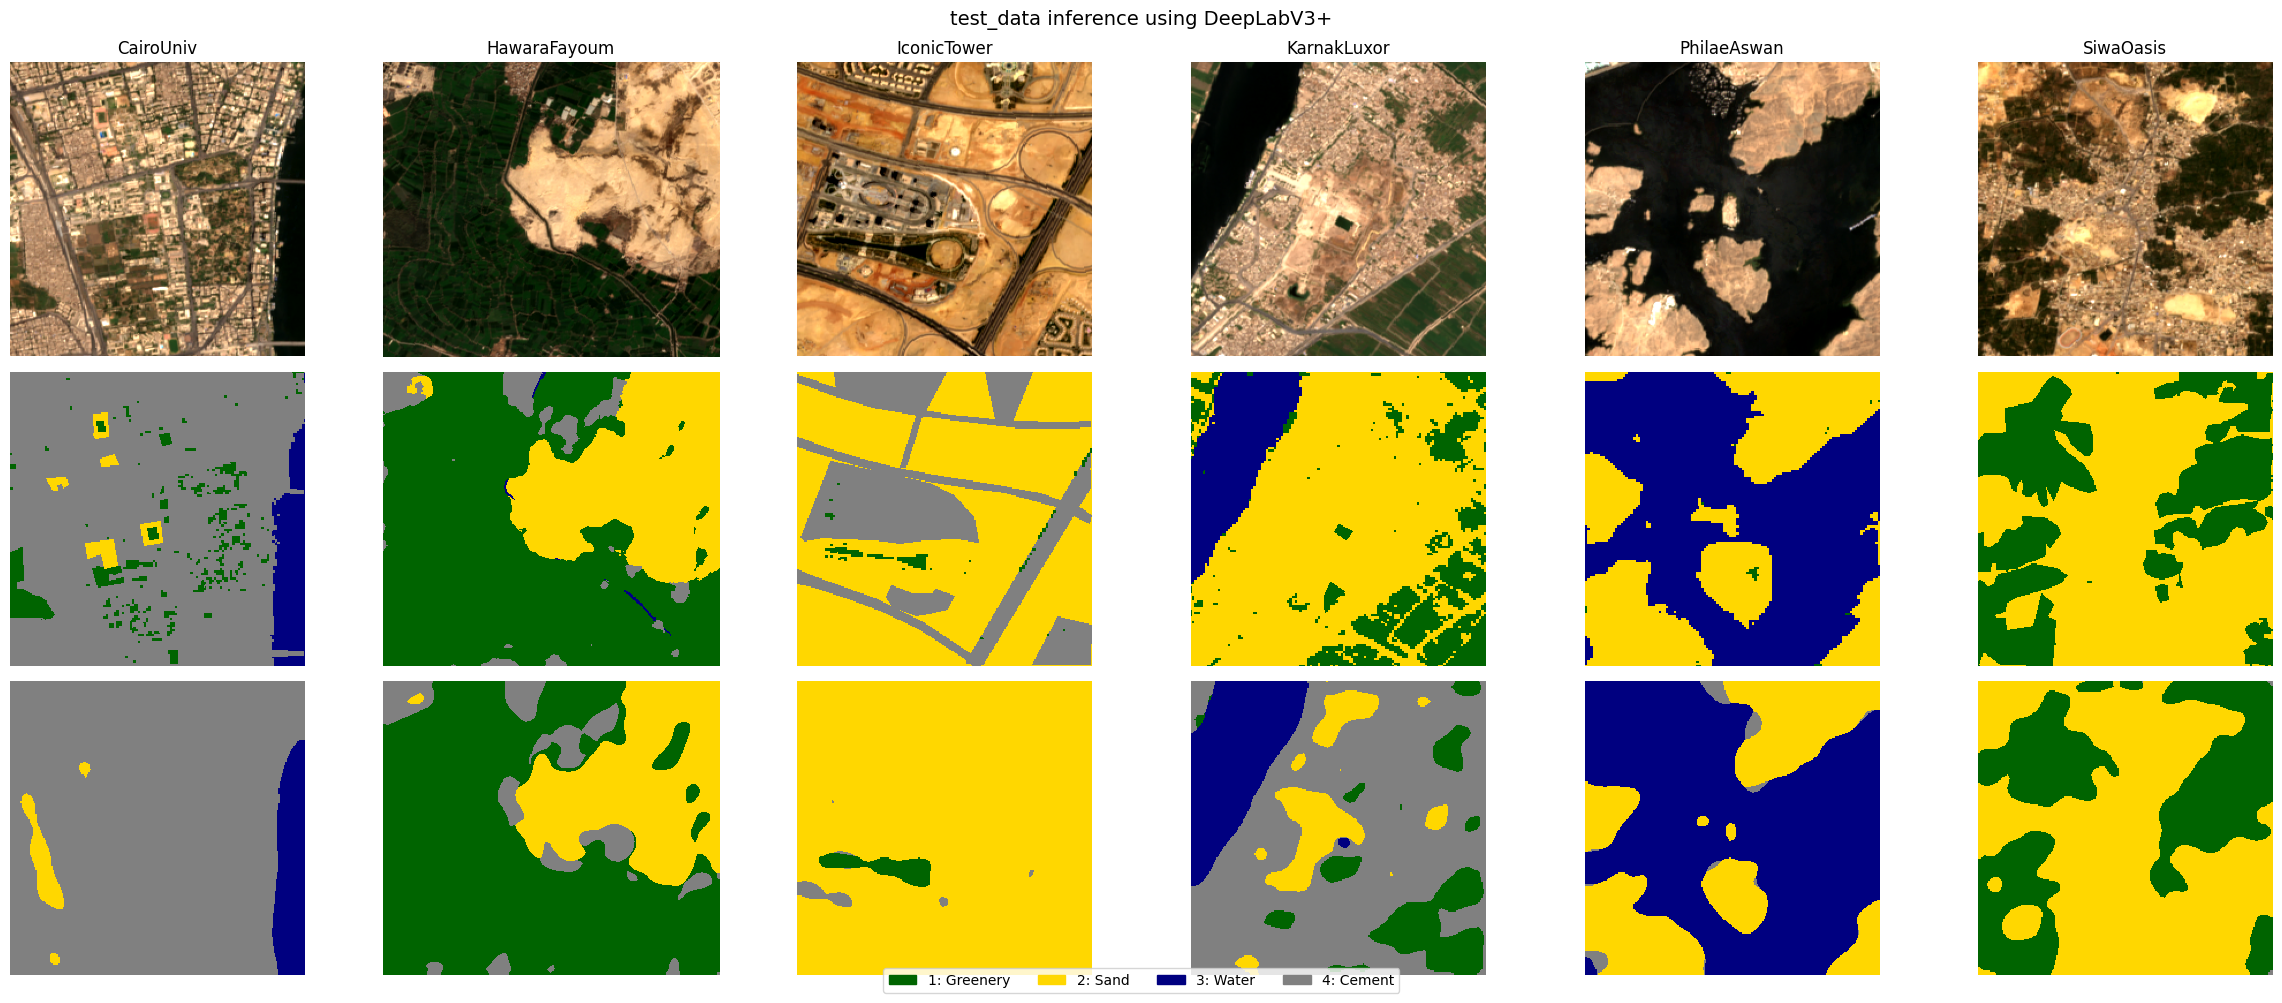

In [26]:
n_samples = len(sample_pairs)
fig, axes = plt.subplots(3, n_samples, figsize=(4*n_samples, 10))
if n_samples == 1:
    axes = np.array(axes).reshape(3, 1)

for col, sample_item in enumerate(sample_pairs):
    sample_name = sample_item['name']
    bundle = predictions_by_site[sample_name]
    rgb = make_rgb(bundle['spectral_cube'])

    axes[0, col].imshow(rgb)
    axes[0, col].set_title(sample_name)
    axes[0, col].axis('off')

    axes[1, col].imshow(bundle['y_true'], cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
    axes[1, col].axis('off')

    axes[2, col].imshow(bundle['y_pred'], cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('RGB', fontsize=10)
axes[1, 0].set_ylabel('Ground Truth', fontsize=10)
axes[2, 0].set_ylabel('Prediction', fontsize=10)

fig.legend(handles=legend_patches, loc='lower center', ncol=len(CLASS_IDS), bbox_to_anchor=(0.5, -0.01))
plt.suptitle('test_data inference using DeepLabV3+', fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
metrics_df.to_csv(METRICS_CSV, index=False)
print(f'Saved metrics: {METRICS_CSV}')

Saved metrics: c:\satellite\project\test_data_inference_metrics_deeplabv3plus_10b.csv
